In [3]:
#julia version:1.11.6
include("Stability_Cavity.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using PyCall
using BSplineKit

In [2]:
function eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
    sigma = 0.72
    cof = CRC_STA.Spatial_mode_BEK(F,-G,H,T,sigma,N_cheb,D,D2,R)
    A0_raw,A1_raw,A2_raw = CRC_STA.assemble_mat(cof :: CRC_STA.COF,D,D2,be,omega,R)
    A0,A1,A2 = CRC_STA.boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    # eigval = conj(eigval)
    return eigval
end

eigsol (generic function with 1 method)

In [ ]:
function Cheb(N)
    θ = range(0,length=N+1,stop=pi)
    x = reshape(-cos.(θ), N+1, 1)
    c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
    X = repeat(x, 1, N+1);
    dX = X - X';
    D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
    D = D - diagm(vec(sum(D, dims=2))); 
    a = 2
    b = 0.6
    c = 0.5
    for i=1:N+1
        D[i,:]=D[i,:].* (1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))^2/(2a*(b .+ 3 * (1-b)*x[i]^2 - 2 * c * (1-b) * x[i]))
    end
    for i=1:N+1
        x[i] = a * (1+b*x[i]+(1-b)*(x[i]^3+c*(1-x[i]^2)))/(1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))
        if x[i] > 20
            x[i] = 20
        end
    end
    D2 = D^2;
    return D,D2,x
 end
 function interp(u0,v0,w0,T0,x,N)
    F = Base.zeros(N+1,1)
    G = Base.zeros(N+1,1)
    H = Base.zeros(N+1,1)
    T = Base.zeros(N+1,1)
    z = range(0,20,2000)
    itu = BSplineKit.interpolate(z, u0 , BSplineOrder(4))
    itv = BSplineKit.interpolate(z, v0 , BSplineOrder(4))
    itw = BSplineKit.interpolate(z, w0 , BSplineOrder(4))
    itt = BSplineKit.interpolate(z, T0 , BSplineOrder(4))
    for i = 1 : N + 1
        F[i,1] = itu(x[i])
        G[i,1] = itv(x[i])
        H[i,1] = itw(x[i])
        T[i,1] = itt(x[i])
    end
    return F,G,H,T
end

In [240]:
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(1.0)
N_cheb = 199
D,D2,x = Cheb(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)

([0.0; 0.00013984719977051298; … ; 5.39202205936666e-26; 5.39202205936666e-26;;], [0.0; 0.00016886061661136603; … ; 1.0; 1.0;;], [2.123850292163728e-26; -3.8456686558661795e-8; … ; -0.884473414805651; -0.884473414805651;;], [1.0; 1.0; … ; 1.0; 1.0;;])

In [ ]:
plot!(x,F)
plot!(x,-G)
plot!(x,H)
# plot!(x,T)

In [280]:
R_ini = 285.36
omega = 0.0
be_ini = 0.078
c_ini = 0.4
Tw = 1.0
num = 1
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
N_cheb = 99
D,D2,x = Cheb(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)
# cur(Tw,omega,R_ini,c_ini,be_ini,num)

([0.0; 0.0005646554831870679; … ; 5.39202205936666e-26; 5.39202205936666e-26;;], [0.0; 0.0006823587942879198; … ; 1.0; 1.0;;], [2.123850292163728e-26; -6.261721820657114e-7; … ; -0.884473414805651; -0.884473414805651;;], [1.0; 1.0; … ; 1.0; 1.0;;])

In [281]:
eigval = eigsol(F,G,H,T,R_ini,omega,be_ini,N_cheb,D,D2,c_ini,30)

30-element Vector{ComplexF64}:
   0.38765570738083627 + 0.0003597619965963731im
    0.2467196124689099 + 0.10980900770577948im
    0.3297640560904056 + 0.2666138094997735im
   0.22804998961866751 + 0.053150574681137416im
    0.3791174728299594 + 0.2700821660774024im
   0.46571754181230607 + 0.3403045287258116im
   0.03239040534561938 - 0.2474546333417249im
    0.5554868703907094 + 0.42739915973027864im
    0.4963500420485485 + 0.46392098198091863im
    0.5096321213027167 + 0.5661902379836543im
                       ⋮
  0.005923476963829222 + 0.25032097617091204im
 0.0063472340699913254 + 0.3015392806943801im
  0.004852286965895292 + 0.20711441469503247im
 0.0036427391995063063 - 0.11915096379009833im
    0.5166877131859118 + 0.7654251769352708im
  0.014679099690146469 - 0.6727913880906928im
 0.0035093441696709138 + 0.17128958754775397im
 0.0022355465357488113 + 0.1424211847942313im
  0.005783691960316084 + 0.36154750449197515im

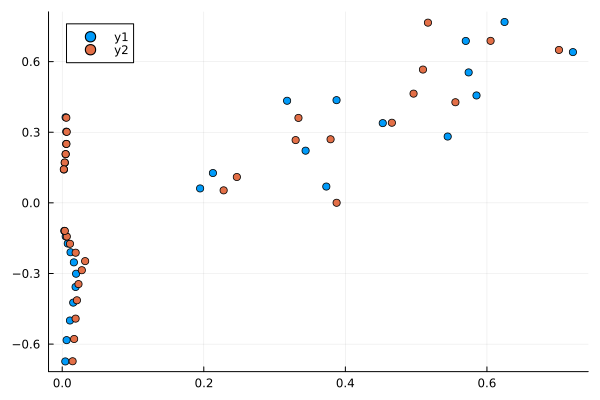

In [282]:
scatter!(real(eigval),imag(eigval))

In [259]:
function cur(Tw,omega,R_ini,c_ini,be_ini,num)
    be_step = -0.0005
    pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
    bone = pyimport("Bone")
    z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
    N_cheb = 99
    D,D2,x = Cheb(N_cheb)
    F,G,H,T = interp(F,G,H,T,x,N_cheb)
    initial = []
    tempvec_1 = [0 0 0 0 0 0 0]
    eigval = 0
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval = eigsol(F,G,H,T,R_ini,omega,be_ini,N_cheb,D,D2,c_ini,num)
    open("output_eig.dat", "a") do io
        write(io,"be=$be_ini,eig=$eigval\n")
    end
    if imag(eigval[1]) < 0
        for be = be_ini :  be_step : -0.5
            sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[end]))
            eigval = eigsol(F,G,H,T,R_ini,omega,be,N_cheb,D,D2,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[end]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 || sig_last2 * sig_now2 < 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    elseif imag(eigval[1]) > 0
        for be = be_ini : - be_step : 0.5
           sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[end]))
            eigval = eigsol(F,G,H,T,R_ini,omega,be,N_cheb,D,D2,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[end]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 || sig_last2 * sig_now2 < 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    end
    total = initial
    be = initial[3] - be_step
    dir = 0
    boundlen = 3
 # CACULATE

    while true
        index = findall(x->x==findmin([total[end,5],total[end,7]])[1],total[end,:])
        c = total[end,index[1] - 1]
        eigval = eigsol(F,G,H,T,total[end,2],omega,be,N_cheb,D,D2,c,num)
        eigval_1 = eigsol(F,G,H,T,total[end,2],omega,be-0.001,N_cheb,D,D2,c,num)
        eigval_2 =  eigsol(F,G,H,T,total[end,2],omega,be+0.001,N_cheb,D,D2,c,num)
        index1 = findmin(x-> (imag(x)) , eigval_1)[2]
        index2 = findmin(x-> (imag(x)) , eigval_2)[2]
        num = 1
        if size(total,1) > 3 && abs(total[end,2] - total[end-1,2]) <=2
            R_step = 0.25
        else
            R_step = 1
        end
        if (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) > 0) || (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) > 0) || dir == -1
            mode = 1
        elseif (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) < 0) || (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) < 0)
            mode = 2
        end
        
        if mode == 1 

            for R = total[end,2] : R_step : 700

                eigval = eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
                index = findmin((imag),eigval)[2]

                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0
                
                eigval = eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end
                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 1
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end

        if mode == 1

            for R = total[end,2]: R_step : 700

                if total[end,3] == be

                    break

                end 
                
                eigval = eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     

                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end
        c = total[end,4]
        eigval = eigsol(F,G,H,T,total[end,2] + 2,omega,be,N_cheb,D,D2,c,num)
        sig = findmin(imag,eigval)[1]
        if size(total,1) > 10 &&total[end,3] != be 
            dir = -1 
            be_step = 0.0009
        else
            if sig > 0
                dir = -1
                be_step = 0.00075
            else
                dir = 1
                be_step = 0.00075
            end
        end
            be -= be_step
        filename = "ome=$(omega)_Tw=$(Tw).dat"
        str1 = "Variables=\"omega\" \"R\" \"beta\" \"alpha_r_1\" \"alpha_i_1\" \"alpha_r_2\" \"alpha_i_2\""
        str2 = "Zone T=\"omega=$(omega),Tw=$(Tw)\""
        open(filename,"w") do io
            println(io,str1)
            println(io,str2)
            writedlm(io,total[2:end,:])
        end
        if total[end,2] > 500 && size(total,1) > 30 
            break
        end
        # app = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat")
        # ori = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
        # if app[end,2] < ori[3,2]
        #     break
        # end
    end
end

cur (generic function with 2 methods)

In [ ]:
cur()

In [ ]:
plot(abs.(eigvec[:,1]))